In [ ]:
pip install segmentation_models_pytorch

In [ ]:
from google.colab import drive
import os

# 1. 드라이브 연결
drive.mount('/content/drive')

# 2. 경로 설정 (보성님의 드라이브 폴더 확인 필수!)
drive_path = '/content/drive/MyDrive/phrithvi/data'
local_path = '/content'

# 3. 데이터 복사 (1.6GB라 약 1~2분 소요됩니다)
print("🚚 대용량 데이터를 로컬로 가져오는 중...")
!cp {drive_path}/master_dem_final.tif {local_path}/dem.tif
!cp {drive_path}/master_mask_final.tif {local_path}/mask.tif
print("✅ 준비 완료!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚚 대용량 데이터를 로컬로 가져오는 중...
✅ 준비 완료!


In [ ]:
import cv2
from tqdm import tqdm

def make_patches(dem_path, mask_path, size=224, stride=112):
    with rasterio.open(dem_path) as src:
        dem = src.read(1).astype(np.float32)
        # 경사도(Slope) 변환: 단층 탐지의 핵심 피처
        dy, dx = np.gradient(dem)
        slope = np.sqrt(dx**2 + dy**2)
        slope = np.clip(slope, 0, np.percentile(slope, 98))
        slope = (slope / slope.max() * 255).astype(np.uint8)

    with rasterio.open(mask_path) as src:
        mask = (src.read(1) > 0).astype(np.uint8)

    x_list, y_list = [], []
    h, w = slope.shape

    for y in tqdm(range(0, h - size, stride)):
        for x in range(0, w - size, stride):
            m_patch = mask[y:y+size, x:x+size]
            s_patch = slope[y:y+size, x:x+size]

            # Hard Negative Mining: 단층이 있거나, 없어도 10% 확률로만 수집
            if np.sum(m_patch) > 0 or np.random.random() < 0.1:
                x_list.append(s_patch)
                y_list.append(m_patch)

    return np.array(x_list), np.array(y_list)

x_train, y_train = make_patches(f'{local_path}/dem.tif', f'{local_path}/mask.tif')
print(f"\n🎉 총 {len(x_train)}장의 정예 패치가 생성되었습니다!")

100%|██████████| 177/177 [00:01<00:00, 153.22it/s]



🎉 총 6406장의 정예 패치가 생성되었습니다!


In [ ]:
import rasterio
import numpy as np

with rasterio.open(f'{local_path}/mask.tif') as src:
    mask_data = src.read(1)
    fault_pixels = np.sum(mask_data > 0)

print(f"📊 이미지 크기: {mask_data.shape}")
print(f"📍 발견된 단층 픽셀: {fault_pixels}개")

if fault_pixels > 0:
    print("✅ 데이터 확인 성공! 학습을 시작해도 좋습니다.")
else:
    print("❌ 경고: 마스크가 비어있습니다. QGIS 작업을 다시 확인해야 합니다.")

📊 이미지 크기: (20012, 20012)
📍 발견된 단층 픽셀: 148332개
✅ 데이터 확인 성공! 학습을 시작해도 좋습니다.


In [ ]:
# ════════════════════════════════════════════════════════
# EDA-A: DEM 기본 통계 + 히스토그램
# ════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import rasterio

local_path = '/content'  # 기존 노트북과 동일한 경로

# DEM + Mask + Slope 다시 로드 (이미 메모리에 있으면 생략 가능)
with rasterio.open(f'{local_path}/dem.tif') as src:
    dem_raw  = src.read(1).astype(np.float32)
    nodata   = src.nodata
    res_m    = src.res[0]   # 픽셀 크기 (m)
    crs_str  = str(src.crs)
    H, W     = src.height, src.width

with rasterio.open(f'{local_path}/mask.tif') as src:
    mask_raw = src.read(1)

# NoData 마스킹
if nodata is not None:
    valid_mask = dem_raw != nodata
else:
    valid_mask = dem_raw > -9000

dem_valid = dem_raw[valid_mask]

# 기본 통계
print('━━━━ DEM 기본 통계 ━━━━')
print(f'  이미지 크기   : {H} × {W} px')
print(f'  해상도        : {res_m:.1f} m/pixel')
print(f'  CRS           : {crs_str}')
print(f'  NoData 값     : {nodata}')
print(f'  NoData 픽셀수 : {(~valid_mask).sum():,}')
print(f'  유효 픽셀수   : {valid_mask.sum():,}')
print()
print('━━━━ Elevation 통계 ━━━━')
print(f'  Mean   : {dem_valid.mean():.2f} m')
print(f'  Median : {np.median(dem_valid):.2f} m')
print(f'  Std    : {dem_valid.std():.2f} m')
print(f'  Min    : {dem_valid.min():.2f} m')
print(f'  Max    : {dem_valid.max():.2f} m')
print(f'  P25    : {np.percentile(dem_valid, 25):.2f} m')
print(f'  P75    : {np.percentile(dem_valid, 75):.2f} m')
print()
print('━━━━ Fault Mask 통계 ━━━━')
fault_px = int((mask_raw > 0).sum())
total_px = H * W
print(f'  전체 픽셀     : {total_px:,}')
print(f'  Fault 픽셀    : {fault_px:,}')
print(f'  Non-Fault 픽셀: {total_px - fault_px:,}')
print(f'  Fault 비율    : {fault_px/total_px*100:.4f}%')
print(f'  Class ratio (neg/pos): {(total_px-fault_px)/fault_px:.1f}:1')

━━━━ DEM 기본 통계 ━━━━
  이미지 크기   : 20012 × 20012 px
  해상도        : 1.0 m/pixel
  CRS           : EPSG:26910
  NoData 값     : -999999.0
  NoData 픽셀수 : 49,021,234
  유효 픽셀수   : 351,458,910

━━━━ Elevation 통계 ━━━━
  Mean   : 416.35 m
  Median : 411.40 m
  Std    : 201.56 m
  Min    : 53.26 m
  Max    : 986.20 m
  P25    : 258.70 m
  P75    : 567.31 m

━━━━ Fault Mask 통계 ━━━━
  전체 픽셀     : 400,480,144
  Fault 픽셀    : 148,332
  Non-Fault 픽셀: 400,331,812
  Fault 비율    : 0.0370%
  Class ratio (neg/pos): 2698.9:1


━━━━ Slope 통계 ━━━━
  Mean   : 69.1850
  Median : 0.4488
  Std    : 6269.2607
  Min    : 0.0000
  Max    : 707598.8125
  P98    : 1.0732  ← clipping threshold


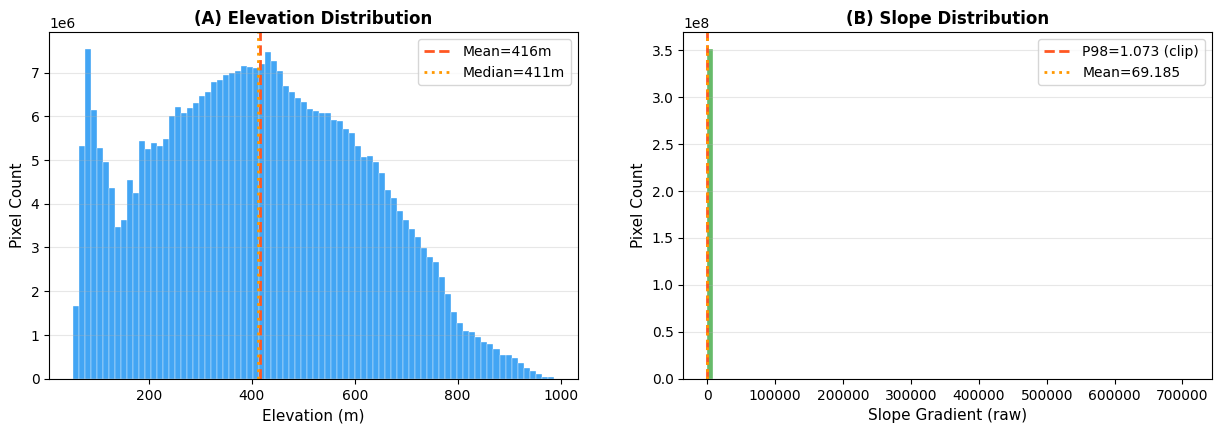

✅ eda_fig1.png 저장 완료


In [ ]:
# ════════════════════════════════════════════════════════
# EDA-B: Figure 1 — Elevation / Slope 히스토그램 + Class Imbalance
# ════════════════════════════════════════════════════════
import cv2

# Slope 계산 (기존 노트북과 동일 방법)
dy, dx = np.gradient(dem_raw)
slope_raw = np.sqrt(dx**2 + dy**2)
slope_valid = slope_raw[valid_mask]

print('━━━━ Slope 통계 ━━━━')
print(f'  Mean   : {slope_valid.mean():.4f}')
print(f'  Median : {np.median(slope_valid):.4f}')
print(f'  Std    : {slope_valid.std():.4f}')
print(f'  Min    : {slope_valid.min():.4f}')
print(f'  Max    : {slope_valid.max():.4f}')
print(f'  P98    : {np.percentile(slope_valid, 98):.4f}  ← clipping threshold')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# (A) Elevation histogram
axes[0].hist(dem_valid.flatten(), bins=80, color='#2196F3',
             edgecolor='white', linewidth=0.3, alpha=0.85)
axes[0].axvline(dem_valid.mean(), color='#FF5722', ls='--', lw=2,
                label=f'Mean={dem_valid.mean():.0f}m')
axes[0].axvline(np.median(dem_valid), color='#FF9800', ls=':', lw=2,
                label=f'Median={np.median(dem_valid):.0f}m')
axes[0].set_xlabel('Elevation (m)', fontsize=11)
axes[0].set_ylabel('Pixel Count', fontsize=11)
axes[0].set_title('(A) Elevation Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# (B) Slope histogram
p98 = np.percentile(slope_valid, 98)
axes[1].hist(slope_valid.flatten(), bins=80, color='#4CAF50',
             edgecolor='white', linewidth=0.3, alpha=0.85)
axes[1].axvline(p98, color='#FF5722', ls='--', lw=2,
                label=f'P98={p98:.3f} (clip)')
axes[1].axvline(slope_valid.mean(), color='#FF9800', ls=':', lw=2,
                label=f'Mean={slope_valid.mean():.3f}')
axes[1].set_xlabel('Slope Gradient (raw)', fontsize=11)
axes[1].set_ylabel('Pixel Count', fontsize=11)
axes[1].set_title('(B) Slope Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# # (C) Class imbalance
# sizes  = [fault_px, total_px - fault_px]
# labels = [f'Fault\n{fault_px:,} px\n({fault_px/total_px*100:.3f}%)',
#           f'Non-Fault\n{total_px-fault_px:,} px\n({(total_px-fault_px)/total_px*100:.3f}%)']
# axes[2].pie(sizes, labels=labels, colors=['#FF5252','#90CAF9'],
#             explode=(0.12, 0), autopct='%1.3f%%', startangle=90,
#             textprops={'fontsize': 9.5})
# axes[2].set_title('(C) Class Imbalance (Target)', fontsize=12, fontweight='bold')

# plt.suptitle('Figure 1: DEM Elevation, Slope & Label Distribution',
#              fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/phrithvi/eda_fig1.png',
#             dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ eda_fig1.png 저장 완료')

━━━━ Patch 통계 ━━━━
  전체 패치     : 6,406
  Fault 포함    : 3,656  (57.1%)
  비어있음      : 2,750  (42.9%)
  양성비율 Mean : 0.32%  (fault 있는 패치만)
  양성비율 Max  : 1.06%

━━━━ Slope 패치 픽셀값 통계 ━━━━
  Mean   : 88.72
  Median : 83.00
  Std    : 72.26
  Min    : 0
  Max    : 255


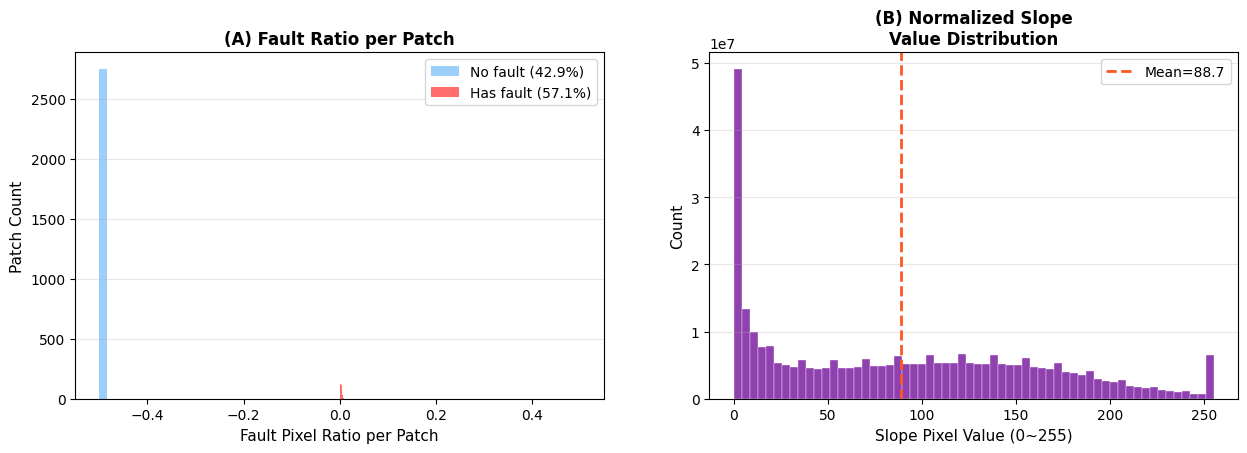

✅ eda_fig2.png 저장 완료


In [ ]:
# ════════════════════════════════════════════════════════
# EDA-C: Figure 2 — Patch 통계 (x_train, y_train 필요)
# ════════════════════════════════════════════════════════
# x_train: (N, 224, 224) slope patches uint8
# y_train: (N, 224, 224) binary mask

# 패치별 양성 픽셀 비율 계산
pos_ratios = y_train.reshape(len(y_train), -1).mean(axis=1)  # (N,)
empty_mask = pos_ratios == 0

print('━━━━ Patch 통계 ━━━━')
print(f'  전체 패치     : {len(x_train):,}')
print(f'  Fault 포함    : {(~empty_mask).sum():,}  ({(~empty_mask).mean()*100:.1f}%)')
print(f'  비어있음      : {empty_mask.sum():,}  ({empty_mask.mean()*100:.1f}%)')
print(f'  양성비율 Mean : {pos_ratios[~empty_mask].mean()*100:.2f}%  (fault 있는 패치만)')
print(f'  양성비율 Max  : {pos_ratios.max()*100:.2f}%')

# Slope 패치 통계
print()
print('━━━━ Slope 패치 픽셀값 통계 ━━━━')
flat = x_train.flatten().astype(np.float32)
print(f'  Mean   : {flat.mean():.2f}')
print(f'  Median : {np.median(flat):.2f}')
print(f'  Std    : {flat.std():.2f}')
print(f'  Min    : {flat.min():.0f}')
print(f'  Max    : {flat.max():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# (A) 패치 양성 픽셀 비율 분포
axes[0].hist(pos_ratios[pos_ratios == 0], bins=1, color='#90CAF9',
             label=f'No fault ({empty_mask.mean()*100:.1f}%)', alpha=0.9, width=0.015)
axes[0].hist(pos_ratios[pos_ratios > 0], bins=50,
             color='#FF5252', label=f'Has fault ({(~empty_mask).mean()*100:.1f}%)', alpha=0.85)
axes[0].set_xlabel('Fault Pixel Ratio per Patch', fontsize=11)
axes[0].set_ylabel('Patch Count', fontsize=11)
axes[0].set_title('(A) Fault Ratio per Patch', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# (B) 슬로프 픽셀값 분포 (정규화 후)
axes[1].hist(flat, bins=60, range=(0, 255), color='#7B1FA2',
             edgecolor='white', linewidth=0.3, alpha=0.85)
axes[1].axvline(flat.mean(), color='#FF5722', ls='--', lw=2,
                label=f'Mean={flat.mean():.1f}')
axes[1].set_xlabel('Slope Pixel Value (0~255)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('(B) Normalized Slope\nValue Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.show()
print('✅ eda_fig2.png 저장 완료')

━━━━ Training Loss 통계 ━━━━
  최초 Train Loss : 1.5966
  최종 Train Loss : 0.6125
  최초 Val Loss   : 1.4306
  최저 Val Loss   : 0.6454  (Epoch 29)
  최종 Val Loss   : 0.6808
  Overfitting gap : 0.0683


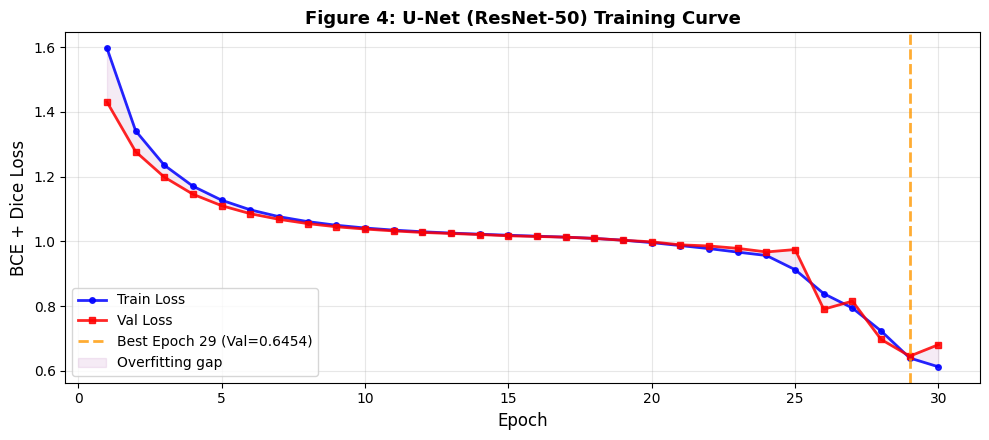

✅ eda_fig4.png 저장 완료


In [ ]:
# ════════════════════════════════════════════════════════
# EDA-F: Figure 4 시각화 (loss curve)
# ════════════════════════════════════════════════════════
epochs = list(range(1, len(train_losses) + 1))
best_ep = int(np.argmin(val_losses)) + 1
best_vl = min(val_losses)

print('━━━━ Training Loss 통계 ━━━━')
print(f'  최초 Train Loss : {train_losses[0]:.4f}')
print(f'  최종 Train Loss : {train_losses[-1]:.4f}')
print(f'  최초 Val Loss   : {val_losses[0]:.4f}')
print(f'  최저 Val Loss   : {best_vl:.4f}  (Epoch {best_ep})')
print(f'  최종 Val Loss   : {val_losses[-1]:.4f}')
print(f'  Overfitting gap : {val_losses[-1] - train_losses[-1]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(epochs, train_losses, 'b-o', markersize=4, lw=2,
        label='Train Loss', alpha=0.85)
ax.plot(epochs, val_losses, 'r-s', markersize=4, lw=2,
        label='Val Loss', alpha=0.85)
ax.axvline(best_ep, color='#FF9800', ls='--', lw=2, alpha=0.8,
           label=f'Best Epoch {best_ep} (Val={best_vl:.4f})')
ax.fill_between(epochs, train_losses, val_losses, alpha=0.08,
                color='purple', label='Overfitting gap')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('BCE + Dice Loss', fontsize=12)
ax.set_title('Figure 4: U-Net (ResNet-50) Training Curve',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phrithvi/eda_fig4.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ eda_fig4.png 저장 완료')

In [ ]:
기존 코드

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import segmentation_models_pytorch as smp

# 1. GPU 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 데이터 준비 (6,390장의 패치를 텐서로 변환)
# 1채널 흑백 이미지를 ResNet50 입력에 맞게 3채널로 복사합니다.
print("🧠 데이터를 GPU 메모리에 최적화하는 중...")
X_tensor = torch.from_numpy(x_train).unsqueeze(1).repeat(1, 3, 1, 1).float() / 255.0
Y_tensor = torch.from_numpy(y_train).unsqueeze(1).float()

# 데이터셋 분리 (훈련 80%, 검증 20%)
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

model = smp.Unet("resnet50", encoder_weights="imagenet", in_channels=3, classes=1).to(device)

focal_loss = smp.losses.FocalLoss(mode=smp.losses.BINARY_MODE)
dice_loss = smp.losses.DiceLoss(mode=smp.losses.BINARY_MODE, from_logits=True)

def criterion(preds, targets):
    return 0.5 * focal_loss(preds, targets) + 0.5 * dice_loss(preds, targets)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# 5. 학습 루프 시작
print(f"🔥 A100 엔진 점화! 총 {len(train_ds)}장의 데이터로 학습을 시작합니다.")

for epoch in range(30): # 6,390장이므로 30 Epoch이면 충분히 수렴합니다.
    model.train()
    train_loss = 0
    for imgs, msks in train_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, msks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # 5에포크마다 중간 결과 출력
    if (epoch + 1) % 5 == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for v_imgs, v_msks in val_loader:
                v_imgs, v_msks = v_imgs.to(device), v_msks.to(device)
                v_loss = criterion(model(v_imgs), v_msks)
                val_loss += v_loss.item()

        print(f"Epoch [{epoch+1}/30] - Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

print("✅ 학습이 완료되었습니다!")

🧠 데이터를 GPU 메모리에 최적화하는 중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

🔥 A100 엔진 점화! 총 5127장의 데이터로 학습을 시작합니다.
Epoch [5/30] - Train Loss: 0.5005 | Val Loss: 0.5003
Epoch [10/30] - Train Loss: 0.4879 | Val Loss: 0.4904
Epoch [15/30] - Train Loss: 0.3361 | Val Loss: 0.3952
Epoch [20/30] - Train Loss: 0.2654 | Val Loss: 0.3546
Epoch [25/30] - Train Loss: 0.2315 | Val Loss: 0.3313
Epoch [30/30] - Train Loss: 0.2138 | Val Loss: 0.3206
✅ 학습이 완료되었습니다!


기존 코드 업그레이드 + 로스 그래프

🧠 데이터를 GPU 메모리에 최적화하는 중...
🔥 A100 엔진 점화! 총 5207장의 데이터로 60 Epoch 학습을 시작합니다.
Epoch [5/60] - Train Loss: 0.5011 | Val Loss: 0.5009
Epoch [10/60] - Train Loss: 0.4969 | Val Loss: 0.4981
Epoch [15/60] - Train Loss: 0.3454 | Val Loss: 0.3854
Epoch [20/60] - Train Loss: 0.2450 | Val Loss: 0.3216
Epoch [25/60] - Train Loss: 0.2067 | Val Loss: 0.2946
Epoch [30/60] - Train Loss: 0.1856 | Val Loss: 0.2746
Epoch [35/60] - Train Loss: 0.1721 | Val Loss: 0.2652
Epoch [40/60] - Train Loss: 0.1641 | Val Loss: 0.2619
Epoch [45/60] - Train Loss: 0.1540 | Val Loss: 0.2477
Epoch [50/60] - Train Loss: 0.1506 | Val Loss: 0.2441
Epoch [55/60] - Train Loss: 0.1411 | Val Loss: 0.2366
Epoch [60/60] - Train Loss: 0.1360 | Val Loss: 0.2321

✅ 60 에포크 학습이 완벽하게 종료되었습니다!
💾 모델 가중치 저장 완료: /content/drive/MyDrive/phrithvi/fault_model_1m_60epoch.pth


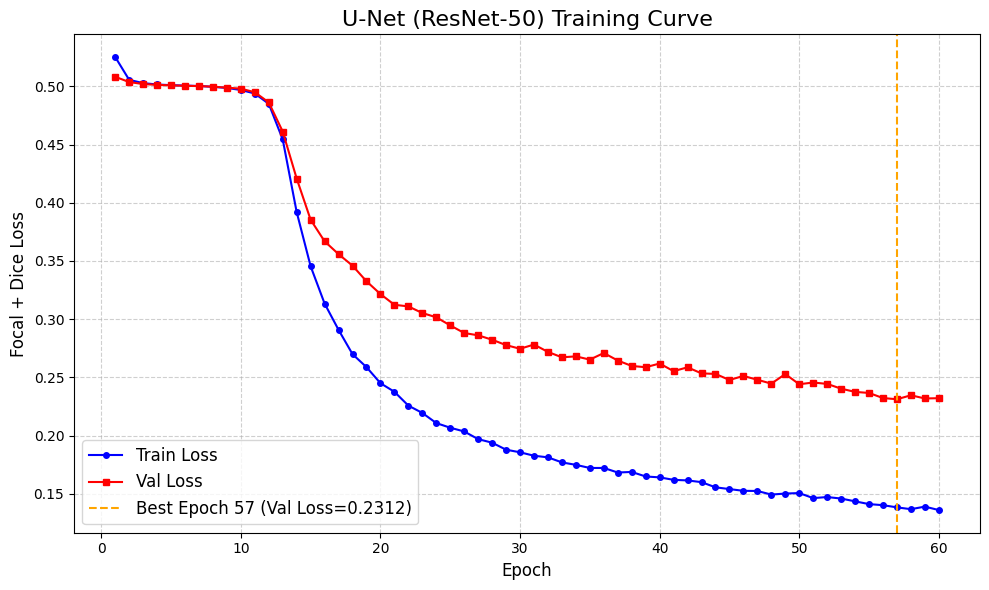

In [ ]:
import torch
import matplotlib.pyplot as plt # 그래프 시각화를 위한 라이브러리 추가
from torch.utils.data import DataLoader, TensorDataset
import segmentation_models_pytorch as smp

# 1. GPU 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 데이터 준비 (6,390장의 패치를 텐서로 변환)
print("🧠 데이터를 GPU 메모리에 최적화하는 중...")
X_tensor = torch.from_numpy(x_train).unsqueeze(1).repeat(1, 3, 1, 1).float() / 255.0
Y_tensor = torch.from_numpy(y_train).unsqueeze(1).float()

# 데이터셋 분리 (훈련 80%, 검증 20%)
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# 3. 모델 및 손실 함수 설정
model = smp.Unet("resnet50", encoder_weights="imagenet", in_channels=3, classes=1).to(device)

focal_loss = smp.losses.FocalLoss(mode=smp.losses.BINARY_MODE)
dice_loss = smp.losses.DiceLoss(mode=smp.losses.BINARY_MODE, from_logits=True)

def criterion(preds, targets):
    return 0.5 * focal_loss(preds, targets) + 0.5 * dice_loss(preds, targets)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# ---------------------------------------------------------
# 🌟 업그레이드된 학습 루프 (그래프 기록 및 모델 저장)
# ---------------------------------------------------------

EPOCHS = 60 # EDA 리포트 가설에 맞춰 60 에포크로 확장!

# 학습/검증 손실을 기록할 빈 리스트 생성
train_losses = []
val_losses = []

print(f"🔥 A100 엔진 점화! 총 {len(train_ds)}장의 데이터로 {EPOCHS} Epoch 학습을 시작합니다.")

for epoch in range(EPOCHS):
    # --- 1) 훈련(Training) 단계 ---
    model.train()
    running_train_loss = 0
    for imgs, msks in train_loader:
        imgs, msks = imgs.to(device), msks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, msks)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss) # 리스트에 기록

    # --- 2) 검증(Validation) 단계 (매 에포크마다 실행) ---
    model.eval()
    running_val_loss = 0
    with torch.no_grad():
        for v_imgs, v_msks in val_loader:
            v_imgs, v_msks = v_imgs.to(device), v_msks.to(device)
            v_loss = criterion(model(v_imgs), v_msks)
            running_val_loss += v_loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss) # 리스트에 기록

    # 화면 출력은 너무 길어지지 않게 5 에포크마다 출력
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("\n✅ 60 에포크 학습이 완벽하게 종료되었습니다!")

# ---------------------------------------------------------
# 💾 4. 모델 영구 저장
# ---------------------------------------------------------
# 드라이브 경로 확인 (폴더가 존재하는지 주의!)
save_path = '/content/drive/MyDrive/phrithvi/fault_model_1m_60epoch.pth'
torch.save(model.state_dict(), save_path)
print(f"💾 모델 가중치 저장 완료: {save_path}")

# ---------------------------------------------------------
# 📈 5. 학습 곡선 (Training Curve) 시각화
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(range(1, EPOCHS + 1), val_losses, label='Val Loss', color='red', marker='s', markersize=4)

# 가장 검증 손실이 낮았던 최고 성능 에포크 찾기
best_epoch = val_losses.index(min(val_losses)) + 1
best_val_loss = min(val_losses)
plt.axvline(x=best_epoch, color='orange', linestyle='--', label=f'Best Epoch {best_epoch} (Val Loss={best_val_loss:.4f})')

# 그래프 꾸미기 (Y축 라벨을 의도한 대로 'Focal + Dice Loss'로 명시!)
plt.title('U-Net (ResNet-50) Training Curve', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Focal + Dice Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#학습 완료 후 구글 드라이브에 모델 가중치 안전하게 저장
save_path = '/content/drive/MyDrive/phrithvi/fault_model_1m_final.pth'
torch.save(model.state_dict(), save_path)
print(f"💾 앗싸! 모델 가중치가 드라이브에 완벽하게 저장되었습니다: {save_path}")

💾 앗싸! 모델 가중치가 드라이브에 완벽하게 저장되었습니다: /content/drive/MyDrive/phrithvi/fault_model_1m_final.pth


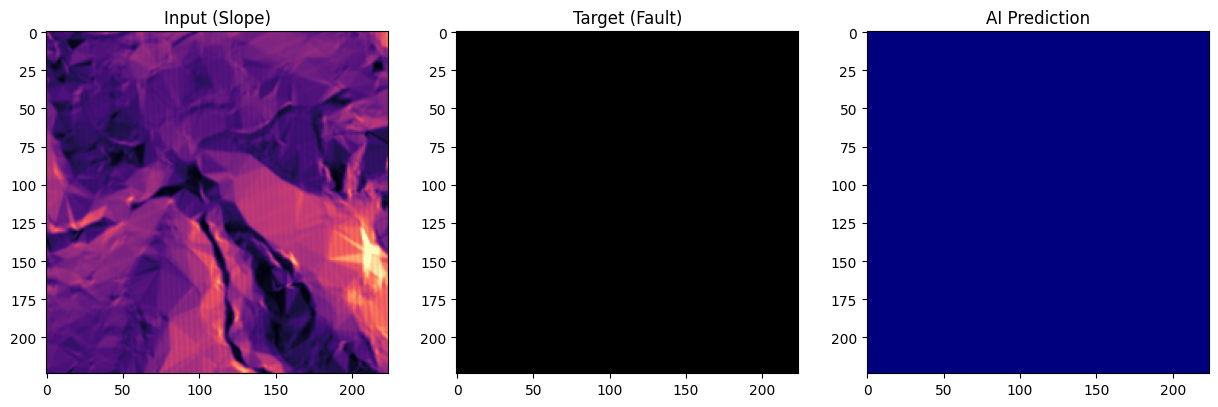

In [ ]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    # 검증 데이터셋에서 무작위 샘플 추출
    image, mask = val_ds[torch.randint(0, len(val_ds), (1,)).item()]
    output = model(image.unsqueeze(0).to(device))
    pred = torch.sigmoid(output).squeeze().cpu().numpy()

# 결과 출력
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image[0].numpy(), cmap='magma'); ax[0].set_title("Input (Slope)")
ax[1].imshow(mask.squeeze().numpy(), cmap='gray'); ax[1].set_title("Target (Fault)")
ax[2].imshow(pred > 0.4, cmap='jet'); ax[2].set_title("AI Prediction")
plt.show()

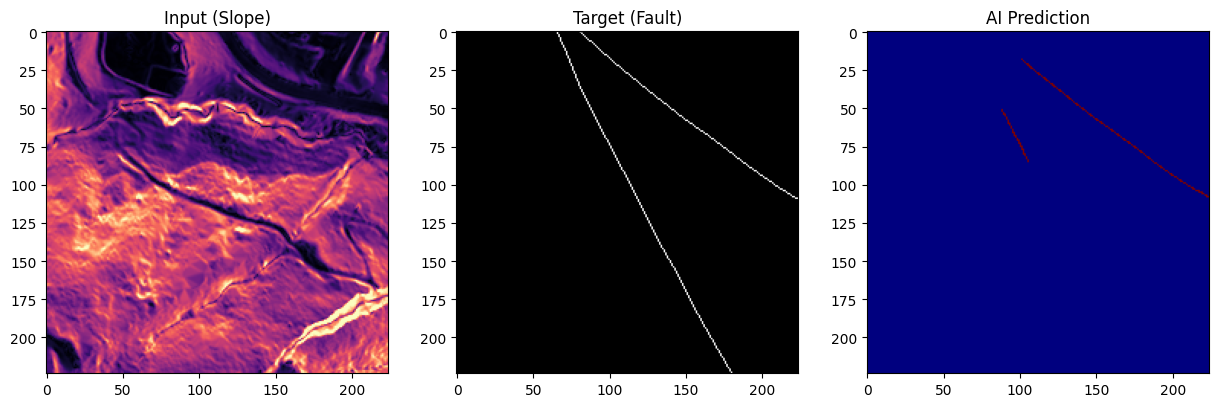

In [ ]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    # 검증 데이터셋에서 무작위 샘플 추출
    image, mask = val_ds[torch.randint(0, len(val_ds), (1,)).item()]
    output = model(image.unsqueeze(0).to(device))
    pred = torch.sigmoid(output).squeeze().cpu().numpy()

# 결과 출력
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image[0].numpy(), cmap='magma'); ax[0].set_title("Input (Slope)")
ax[1].imshow(mask.squeeze().numpy(), cmap='gray'); ax[1].set_title("Target (Fault)")
ax[2].imshow(pred > 0.4, cmap='jet'); ax[2].set_title("AI Prediction")
plt.show()

In [ ]:
import rasterio
import numpy as np

print("🔍 원본 데이터 팩트 체크를 시작합니다...")

# 1. 함수 밖에서 원본 지도를 안전하게 다시 열기
with rasterio.open(f'{local_path}/dem.tif') as src:
    dem_raw = src.read(1).astype(np.float32)

# 2. 클리핑(전처리) 없는 진짜 '쌩얼' 경사도 계산
dy, dx = np.gradient(dem_raw)
raw_slope = np.sqrt(dx**2 + dy**2)

# 3. 충격적인 통계치 눈으로 확인하기
print("\n=== 쌩얼(Raw) 경사도 데이터 팩트 체크 ===")
print(f"Mean (평균): {np.nanmean(raw_slope):.3f}")
print(f"Median (중앙값): {np.nanmedian(raw_slope):.3f}")
print(f"Std (표준편차): {np.nanstd(raw_slope):.3f}")
print(f"Max (최댓값): {np.nanmax(raw_slope):.3f}")
print(f"P98 (상위 2% 컷오프): {np.nanpercentile(raw_slope, 98):.3f}")

🔍 원본 데이터 팩트 체크를 시작합니다...

=== 쌩얼(Raw) 경사도 데이터 팩트 체크 ===
Mean (평균): 121.024
Median (중앙값): 0.389
Std (표준편차): 8304.408
Max (최댓값): 1118726.750
P98 (상위 2% 컷오프): 1.052


🕵️‍♂️ 괴물 픽셀(Max Slope) 추적을 시작합니다...
🚨 범인 발견! 픽셀 위치: Y=20011, X=2528
해당 픽셀의 경사도: 1118726.750
해당 픽셀 주변의 원래 해발고도(DEM): -999999.000 m


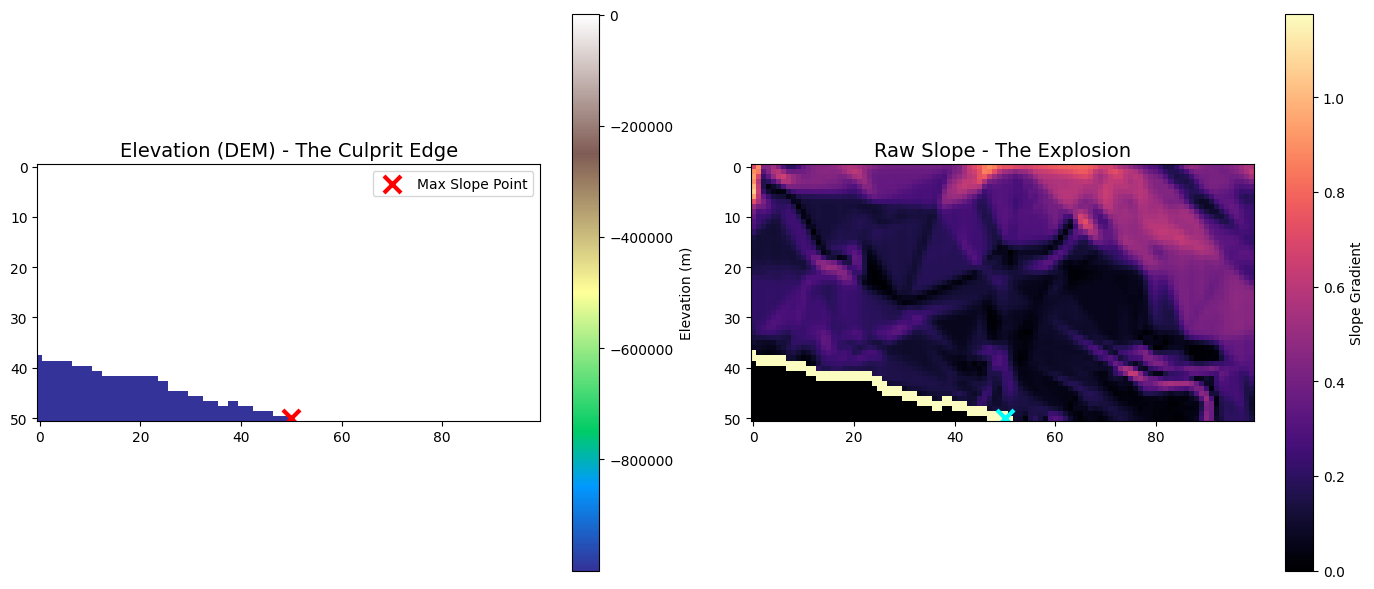

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("🕵️‍♂️ 괴물 픽셀(Max Slope) 추적을 시작합니다...")

# 1. 111만짜리 최댓값이 있는 (Y, X) 좌표 찾기
max_y, max_x = np.unravel_index(np.nanargmax(raw_slope), raw_slope.shape)
print(f"🚨 범인 발견! 픽셀 위치: Y={max_y}, X={max_x}")
print(f"해당 픽셀의 경사도: {raw_slope[max_y, max_x]:.3f}")
print(f"해당 픽셀 주변의 원래 해발고도(DEM): {dem_raw[max_y, max_x]:.3f} m")

# 2. 범인 픽셀을 중심으로 100x100 크기의 주변 지형 잘라오기
window = 50
y_min, y_max = max(0, max_y - window), min(raw_slope.shape[0], max_y + window)
x_min, x_max = max(0, max_x - window), min(raw_slope.shape[1], max_x + window)

dem_patch = dem_raw[y_min:y_max, x_min:x_max]
slope_patch = raw_slope[y_min:y_max, x_min:x_max]

# 3. 사진 찍기 (시각화)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 원래 해발고도 지형
im1 = axes[0].imshow(dem_patch, cmap='terrain')
axes[0].set_title('Elevation (DEM) - The Culprit Edge', fontsize=14)
axes[0].scatter([max_x - x_min], [max_y - y_min], color='red', marker='x', s=150, linewidths=3, label='Max Slope Point')
fig.colorbar(im1, ax=axes[0], label='Elevation (m)')
axes[0].legend()

# 오른쪽: 경사도 폭발 현장
im2 = axes[1].imshow(slope_patch, cmap='magma', vmax=np.nanpercentile(raw_slope, 99)) # 주변도 보이게 P99로 밝기 조절
axes[1].set_title('Raw Slope - The Explosion', fontsize=14)
axes[1].scatter([max_x - x_min], [max_y - y_min], color='cyan', marker='x', s=150, linewidths=3)
fig.colorbar(im2, ax=axes[1], label='Slope Gradient')

plt.tight_layout()
plt.show()